In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# SPMP vOTU prevalence

num_samples_spmp = 109

df_v = pd.read_excel('../data/Supplementary_Data_1_vOTU_metadata.xlsx', usecols=['votu_id','VFC','perc_prevalence'])

df_topvfc = df_v[df_v['VFC'].isin(range(1,13))].sort_values('perc_prevalence', ascending=False)

First, download the [GPD sample metadata](https://ftp.ebi.ac.uk/pub/databases/metagenomics/genome_sets/gut_phage_database/GutMetagenomes_metadata.csv) CSV file and save it in `data/` directory.

Only samples with >50M reads were used to assess prevalence of ≥50% complete SPMP and reference vOTUs.

In [ ]:
df_gpd = pd.read_csv('../data/GutMetagenomes_metadata.csv', nrows=28060, index_col=False)

df_gpd50m = df_gpd[df_gpd.read_count > 50e6]

num_samples_gpd = len(df_gpd50m)

C:\Users\chenhr\AppData\Local\Temp\ipykernel_43656\2923720325.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_gpd = pd.read_csv('../data/GutMetagenomes_metadata.csv', nrows=28060, index_col=False)


In [3]:
# global vOTU prevalence

dfg = pd.read_csv('../data/global_vOTU_prevalence.tsv', sep='\t')

dfg1 = dfg.groupby('votu_id', as_index=False).agg(
    num_samples_detected = ('sample_id', 'count'),
    VFC = ('VFC', 'first'))
dfg1['perc_prevalence'] = dfg1.num_samples_detected/num_samples_gpd*100

dfg_topvfc = dfg1[dfg1['VFC'].isin(range(1,13))].sort_values('perc_prevalence', ascending=False)

### Supplementary Fig. 11A: vOTU prevalence in top VFCs

In [4]:
from matplotlib import cycler

tab10_colors = plt.cm.tab10.colors
tab20_colors = (plt.cm.tab20.colors[1], plt.cm.tab20.colors[3])
custom_colors = tab10_colors + tab20_colors
plt.rc('axes', prop_cycle=cycler('color', custom_colors))

C:\Users\chenhr\AppData\Local\Temp\ipykernel_43656\2579141515.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='VFC', y='perc_prevalence', data=df_topvfc, palette=custom_colors, ax=ax[0])
C:\Users\chenhr\AppData\Local\Temp\ipykernel_43656\2579141515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='VFC', y='perc_prevalence', data=dfg_topvfc, palette=custom_colors, ax=ax[1])


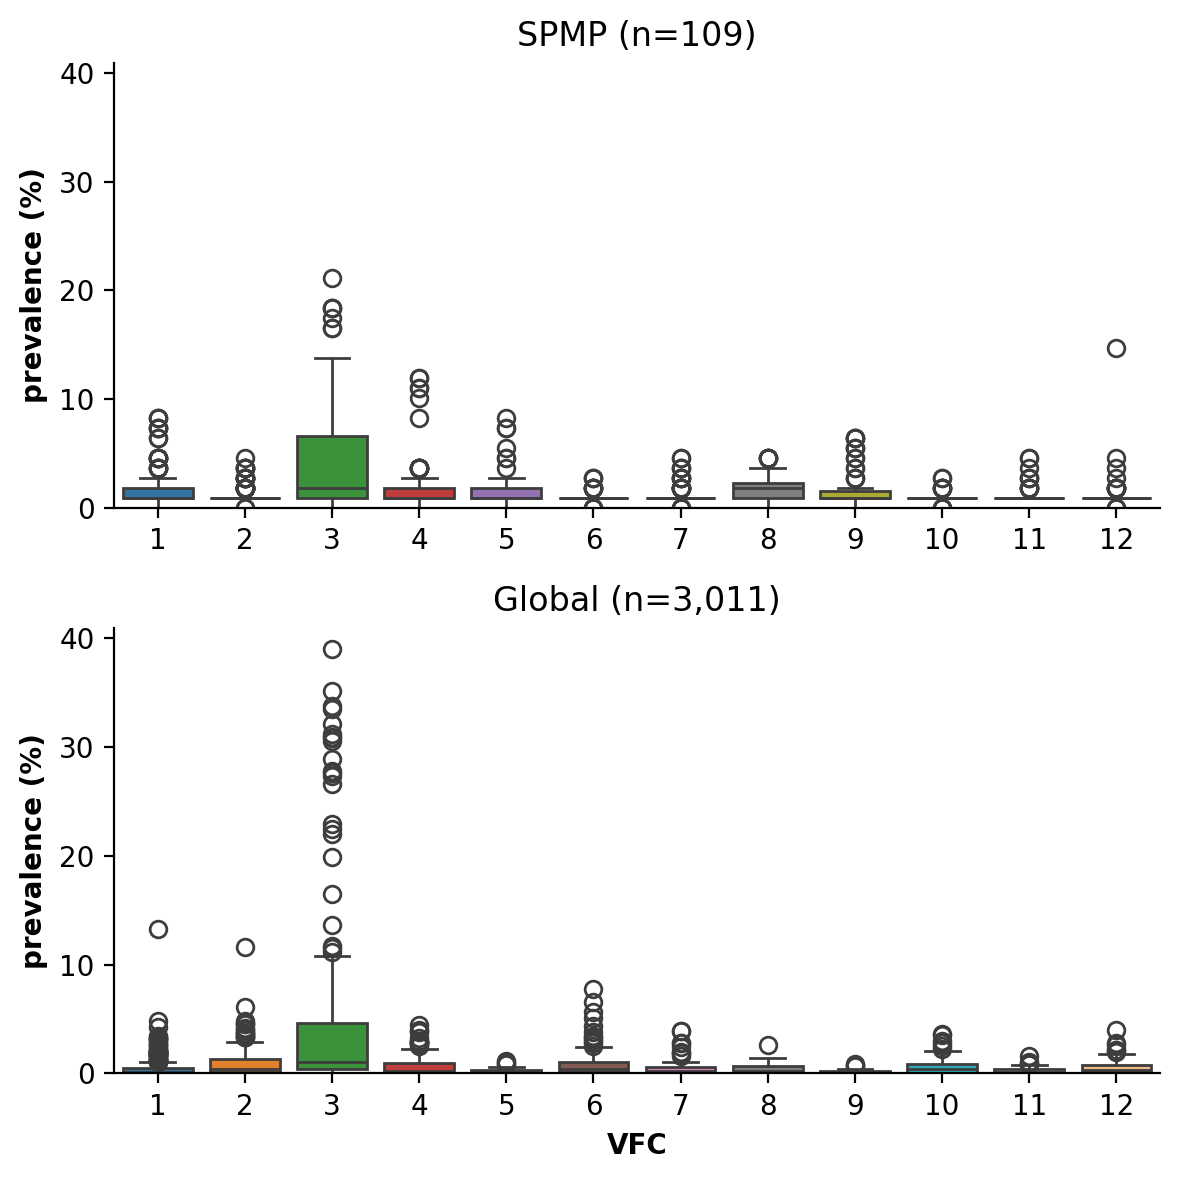

In [5]:
fig, ax = plt.subplots(2, figsize=(6, 6), dpi=200, sharey=True)

sns.boxplot(x='VFC', y='perc_prevalence', data=df_topvfc, palette=custom_colors, ax=ax[0])
sns.boxplot(x='VFC', y='perc_prevalence', data=dfg_topvfc, palette=custom_colors, ax=ax[1])

ax[0].set_xlabel('')
ax[1].set_xlabel('VFC', fontweight='bold')
ax[0].set_xticks(range(12), [str(i) for i in range(1, 13)])
ax[1].set_xticks(range(12), [str(i) for i in range(1, 13)])
ax[0].set_ylabel('prevalence (%)', fontweight='bold')
ax[1].set_ylabel('prevalence (%)', fontweight='bold')
y1,y2 = plt.ylim()
ax[0].set_ylim(0, y2)
ax[1].set_ylim(0, y2)
ax[0].set_title(f'SPMP (n={num_samples_spmp})')
ax[1].set_title(f'Global (n={num_samples_gpd:,})')

sns.despine()
plt.tight_layout()

### Supplementary Fig. 11B: VFC prevalence vs. % of vOTUs added
vOTUs are added in order of decreasing prevalence.

In [6]:
df_va = pd.read_excel('../data/Supplementary_Data_7_vOTU_and_MAG_abundance_estimation.xlsx', sheet_name='votu-bulk', usecols=['votu_id','sample_id'])

In [7]:
vfc_prevalence_by_votu_frac = {i: [] for i in range(1, 13)}

for vfc, df in df_topvfc.groupby('VFC'):
    vlist = df.votu_id.tolist()
    for i in range(len(vlist)):
        vfc_prevalence_by_votu_frac[vfc] += [df_va[df_va.votu_id.isin(vlist[:i+1])].sample_id.nunique()/num_samples_spmp*100]

In [8]:
vfc_gprevalence_by_votu_frac = {i: [] for i in range(1, 13)}

for vfc, df in dfg_topvfc.groupby('VFC'):
    vlist = df.votu_id.tolist()
    for i in range(len(vlist)):
        vfc_gprevalence_by_votu_frac[vfc] += [dfg[dfg.votu_id.isin(vlist[:i+1])]['sample_id'].nunique()/num_samples_gpd*100]

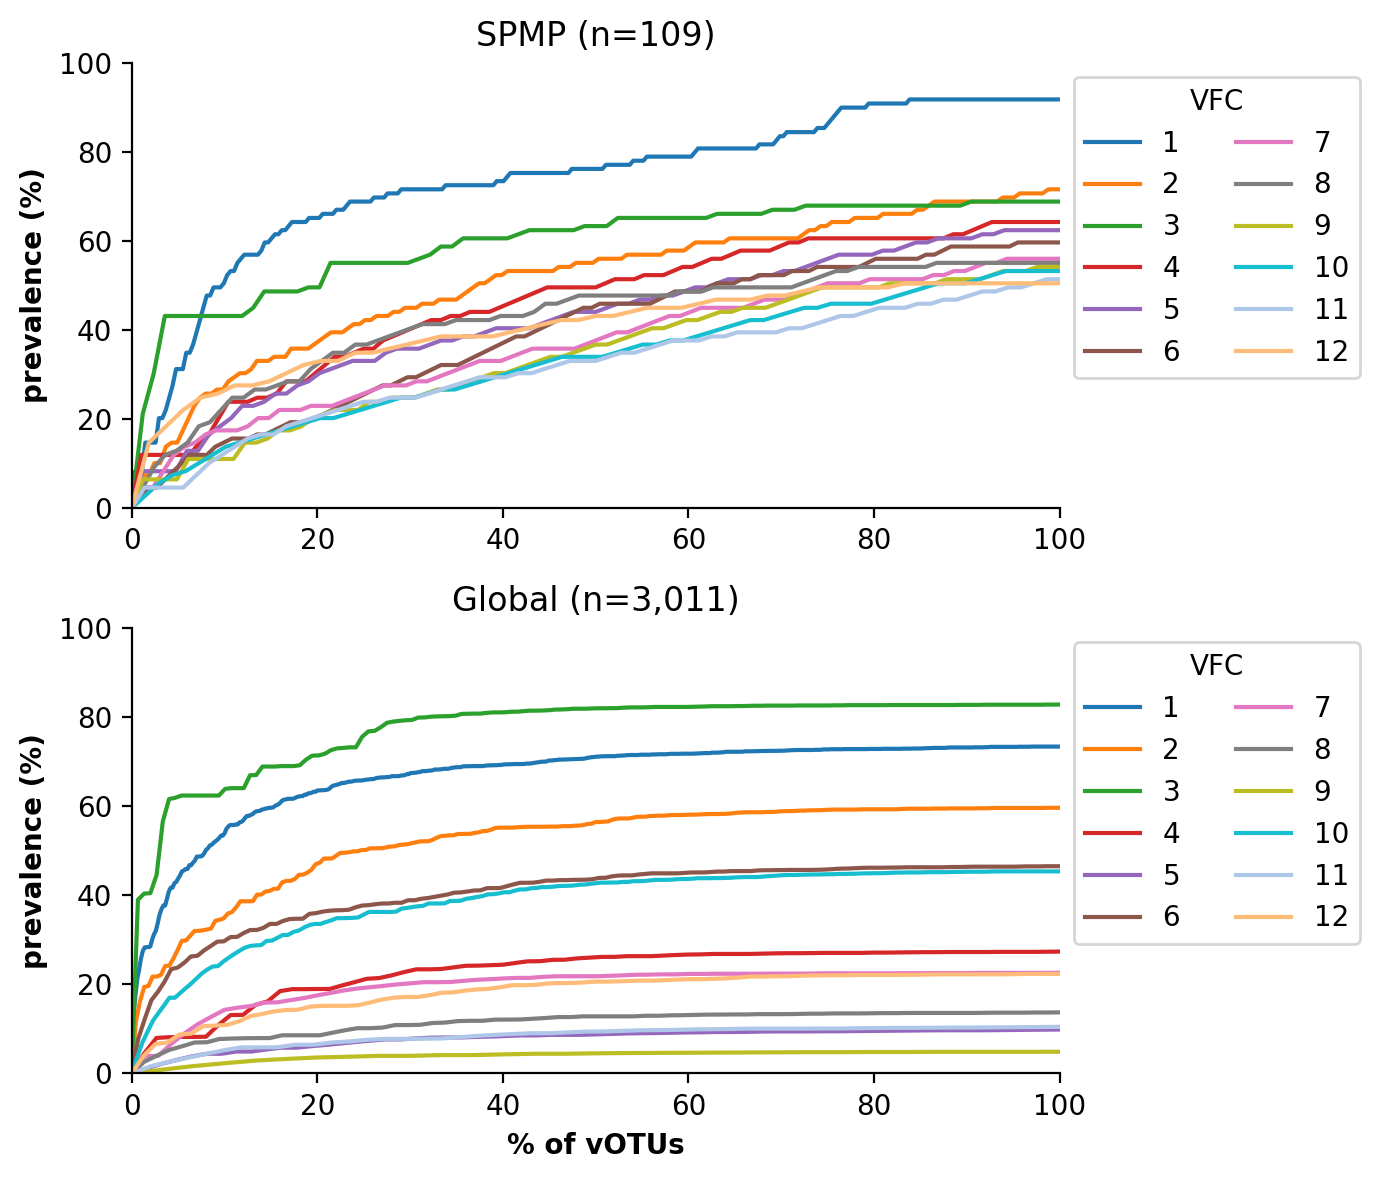

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(7, 6), dpi=200)

ax = axes[0]
for i, (vfc, data) in enumerate(vfc_prevalence_by_votu_frac.items()):
    x = np.linspace(0, 100, len(data)+1) # rescale x-axis to 0-100% of vOTUs considered in vOTU
    ax.plot(x, [0] + data, label=f'{vfc}') # include an initial point where none of the vOTUs are considered

ax.set_title(f'SPMP (n={num_samples_spmp})')
ax.set_ylabel('prevalence (%)', fontweight='bold')
ax.set_xlim(0,100)
ax.set_ylim(0,100)
ax.legend(title='VFC', ncol=2, loc='upper left', bbox_to_anchor=(1,1))

ax = axes[1]
for i, (vfc, data) in enumerate(vfc_gprevalence_by_votu_frac.items()):
    x = np.linspace(0, 100, len(data)+1)
    ax.plot(x, [0] + data, label=f'{vfc}')

ax.set_title(f'Global (n={num_samples_gpd:,})')
ax.set_xlabel('% of vOTUs', fontweight='bold')
ax.set_ylabel('prevalence (%)', fontweight='bold')
ax.set_xlim(0,100)
ax.set_ylim(0,100)
ax.legend(title='VFC', ncol=2, loc='upper left', bbox_to_anchor=(1,1))

sns.despine()
plt.tight_layout()